In [4]:
#===================================================
#PROJECT -1 Customer Churn Predictor
#Author--------Ashim
#===================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully")

All libraries imported successfully


In [5]:
import os
print(os.listdir('.'))
print("\n curent working directory")
print(os.getcwd())   

['customer_churn_project.ipynb', 'Telco-Customer-Churn.csv']

 curent working directory
c:\Users\me_co\OneDrive\文档\VSCODE\customer_churn_project


In [6]:
df=pd.read_csv("Telco-Customer-Churn.csv")
print("shape",df.shape)
df.head()

shape (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
for col in df.columns:
    print(col)

customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [8]:
print("Data Types")
print(df.dtypes)

Data Types
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [11]:
print("Total charges data type:",df['TotalCharges'].dtype)
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
print("missing values after conversion")
print(df.isnull().sum())

Total charges data type: str
missing values after conversion
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [12]:
print("rows before",len(df))
df=df.dropna(subset=['TotalCharges'])
print("Rows after:",len(df))

print("missing values remaining")
print(df.isnull().sum())


rows before 7043
Rows after: 7032
missing values remaining
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [13]:
df=df.drop(columns=['customerID'])
print("columns remaining:",len(df.columns))
print(df.columns.tolist())

columns remaining: 20
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [14]:
print("Churn Distribution")
print(df['Churn'].value_counts())

print("\n in percentage")
print(df['Churn'].value_counts(normalize=True)*100)

Churn Distribution
Churn
No     5163
Yes    1869
Name: count, dtype: int64

 in percentage
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


C:\Users\me_co\AppData\Local\Temp\ipykernel_2808\584814077.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="viridis")


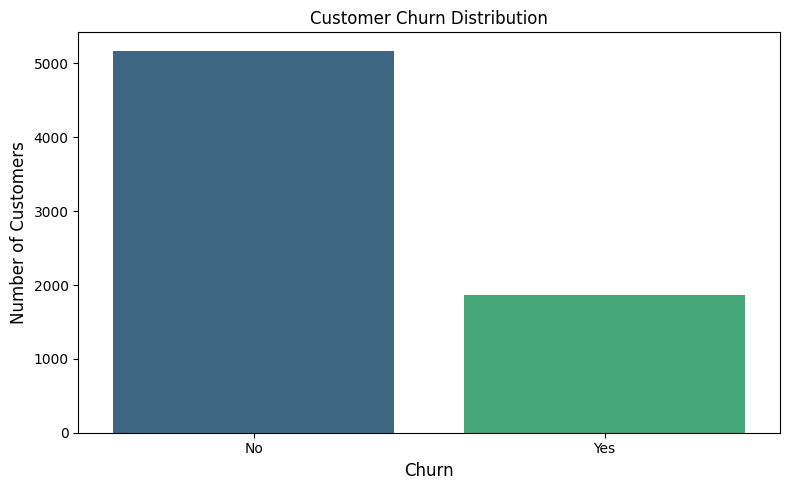

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x="Churn", data=df, palette="viridis")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn",fontsize=12)
plt.ylabel("Number of Customers",fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\me_co\AppData\Local\Temp\ipykernel_2808\2543640523.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette=colors)


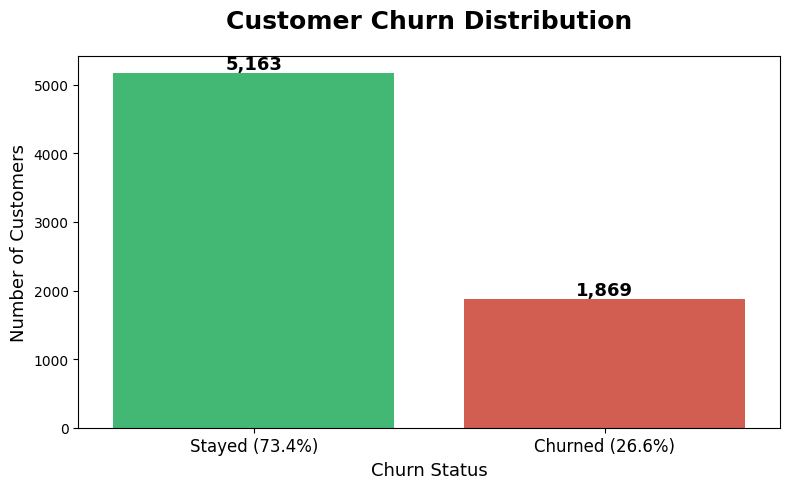

In [16]:
# Beautiful version
plt.figure(figsize=(8, 5))

# Custom colors
colors = ['#2ecc71', '#e74c3c']  # green for stayed, red for churned

ax = sns.countplot(x='Churn', data=df, palette=colors)

# Add number labels ON TOP of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=13, fontweight='bold')

# Styling
plt.title('Customer Churn Distribution', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Churn Status', fontsize=13)
plt.ylabel('Number of Customers', fontsize=13)
plt.xticks([0, 1], ['Stayed (73.4%)', 'Churned (26.6%)'], fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\me_co\AppData\Local\Temp\ipykernel_2808\579185573.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Contract', data=df, palette=colors)


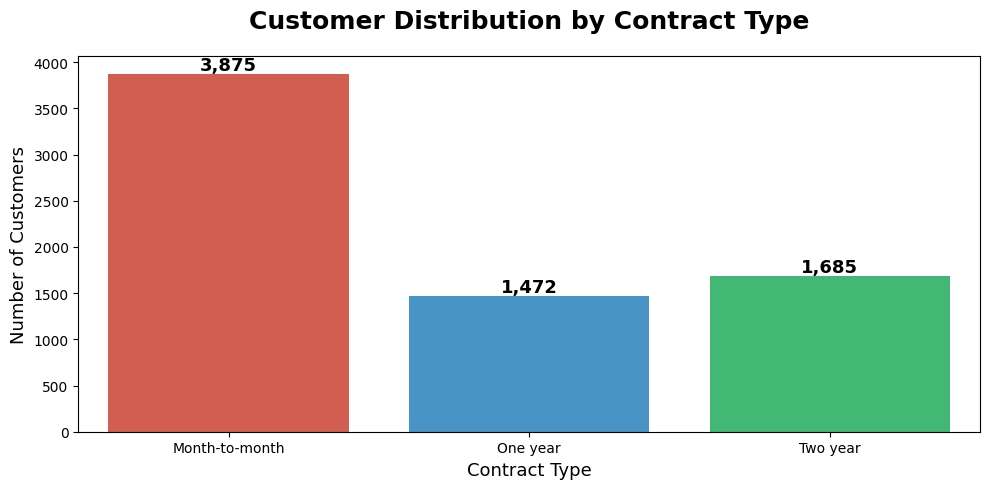

In [17]:
# How are customers distributed across contract types?
plt.figure(figsize=(10, 5))

colors = ['#e74c3c', '#3498db', '#2ecc71']

ax = sns.countplot(x='Contract', data=df, palette=colors)

# Add labels on top
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.title('Customer Distribution by Contract Type', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Contract Type', fontsize=13)
plt.ylabel('Number of Customers', fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
print(pd.crosstab(df['Churn'],df['Contract']))

print("in percentage")
print(pd.crosstab(df['Churn'],df['Contract'],normalize='index')*100)


Contract  Month-to-month  One year  Two year
Churn                                       
No                  2220      1306      1637
Yes                 1655       166        48
in percentage
Contract  Month-to-month   One year   Two year
Churn                                         
No             42.998257  25.295371  31.706372
Yes            88.550027   8.881755   2.568218


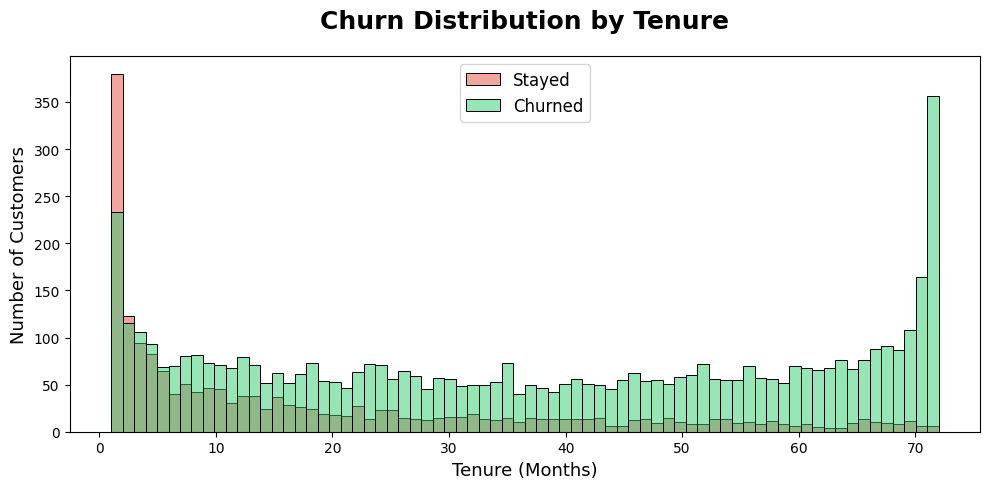

In [19]:
# Tenure vs Churn - does how long someone stays affect churn?
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='tenure', hue='Churn', 
             bins=72, palette=['#2ecc71', '#e74c3c'])

plt.title('Churn Distribution by Tenure', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Tenure (Months)', fontsize=13)
plt.ylabel('Number of Customers', fontsize=13)
plt.legend(['Stayed', 'Churned'], fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
def categorize_tenure(tenure):
    if tenure<=12:
        return 'New' 
    elif tenure<=24:
        return 'Growing'
    elif tenure<=48:
        return 'Mature'
    else:
        return 'Loyal'
df['tenure_group']=df['tenure'].apply(categorize_tenure)
print('Tenure group created')
print(df['tenure_group'].value_counts())



Tenure group created
tenure_group
Loyal      2239
New        2175
Mature     1594
Growing    1024
Name: count, dtype: int64


In [21]:
print(pd.crosstab(df['tenure_group'],df['Churn'],normalize='index')*100)


Churn                No        Yes
tenure_group                      
Growing       71.289062  28.710938
Loyal         90.486824   9.513176
Mature        79.611041  20.388959
New           52.321839  47.678161


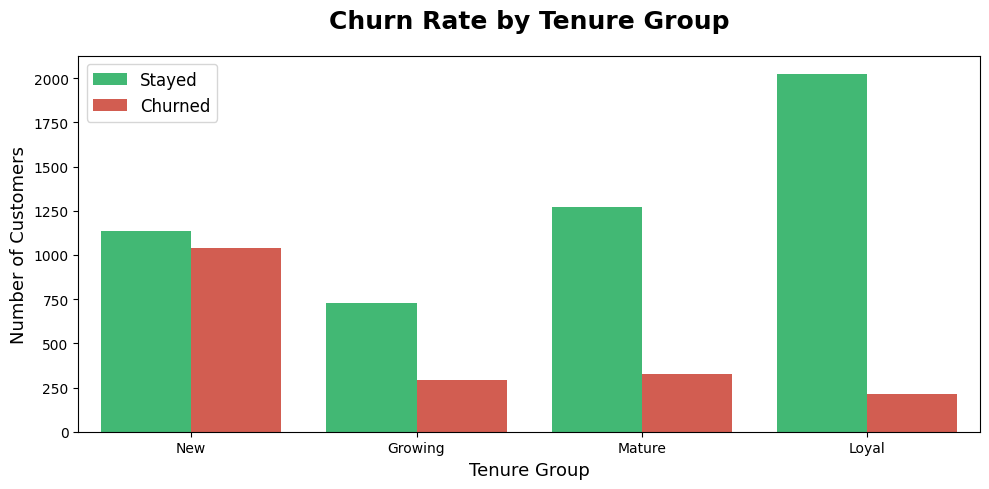

In [22]:
# Visualize churn rate by tenure group
plt.figure(figsize=(10, 5))

# Order groups logically
order = ['New', 'Growing', 'Mature', 'Loyal']

sns.countplot(x='tenure_group', hue='Churn', data=df,
              order=order, palette=['#2ecc71', '#e74c3c'])

plt.title('Churn Rate by Tenure Group',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Tenure Group', fontsize=13)
plt.ylabel('Number of Customers', fontsize=13)
plt.legend(['Stayed', 'Churned'], fontsize=12)
plt.tight_layout()
plt.show()

In [23]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group'],
      dtype='str')

In [24]:
df['charges_ratio']=df['MonthlyCharges']/df['TotalCharges']
service_columns = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                   'DeviceProtection', 'TechSupport', 
                   'StreamingTV', 'StreamingMovies']
df['total_services']=(df[service_columns]=="Yes").sum(axis=1)
print(df)

      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female              0     Yes         No       1           No   
1       Male              0      No         No      34          Yes   
2       Male              0      No         No       2          Yes   
3       Male              0      No         No      45           No   
4     Female              0      No         No       2          Yes   
...      ...            ...     ...        ...     ...          ...   
7038    Male              0     Yes        Yes      24          Yes   
7039  Female              0     Yes        Yes      72          Yes   
7040  Female              0     Yes        Yes      11           No   
7041    Male              1     Yes         No       4          Yes   
7042    Male              0      No         No      66          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
0     No phone service             DSL             No          Yes  ... 

In [25]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,charges_ratio,total_services
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,New,1.000000,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,No,Mature,0.030140,3
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,New,0.497920,3
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Mature,0.022980,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,New,0.466205,1


In [31]:
print(df.shape)
print("missing values",df.isnull().sum().sum())

(7032, 23)
missing values 0


In [32]:
df.to_csv('Churn_cleaned.csv',index=False)
print("Dataset saved successfully! ✅")
print("File: churn_cleaned.csv")

Dataset saved successfully! ✅
File: churn_cleaned.csv


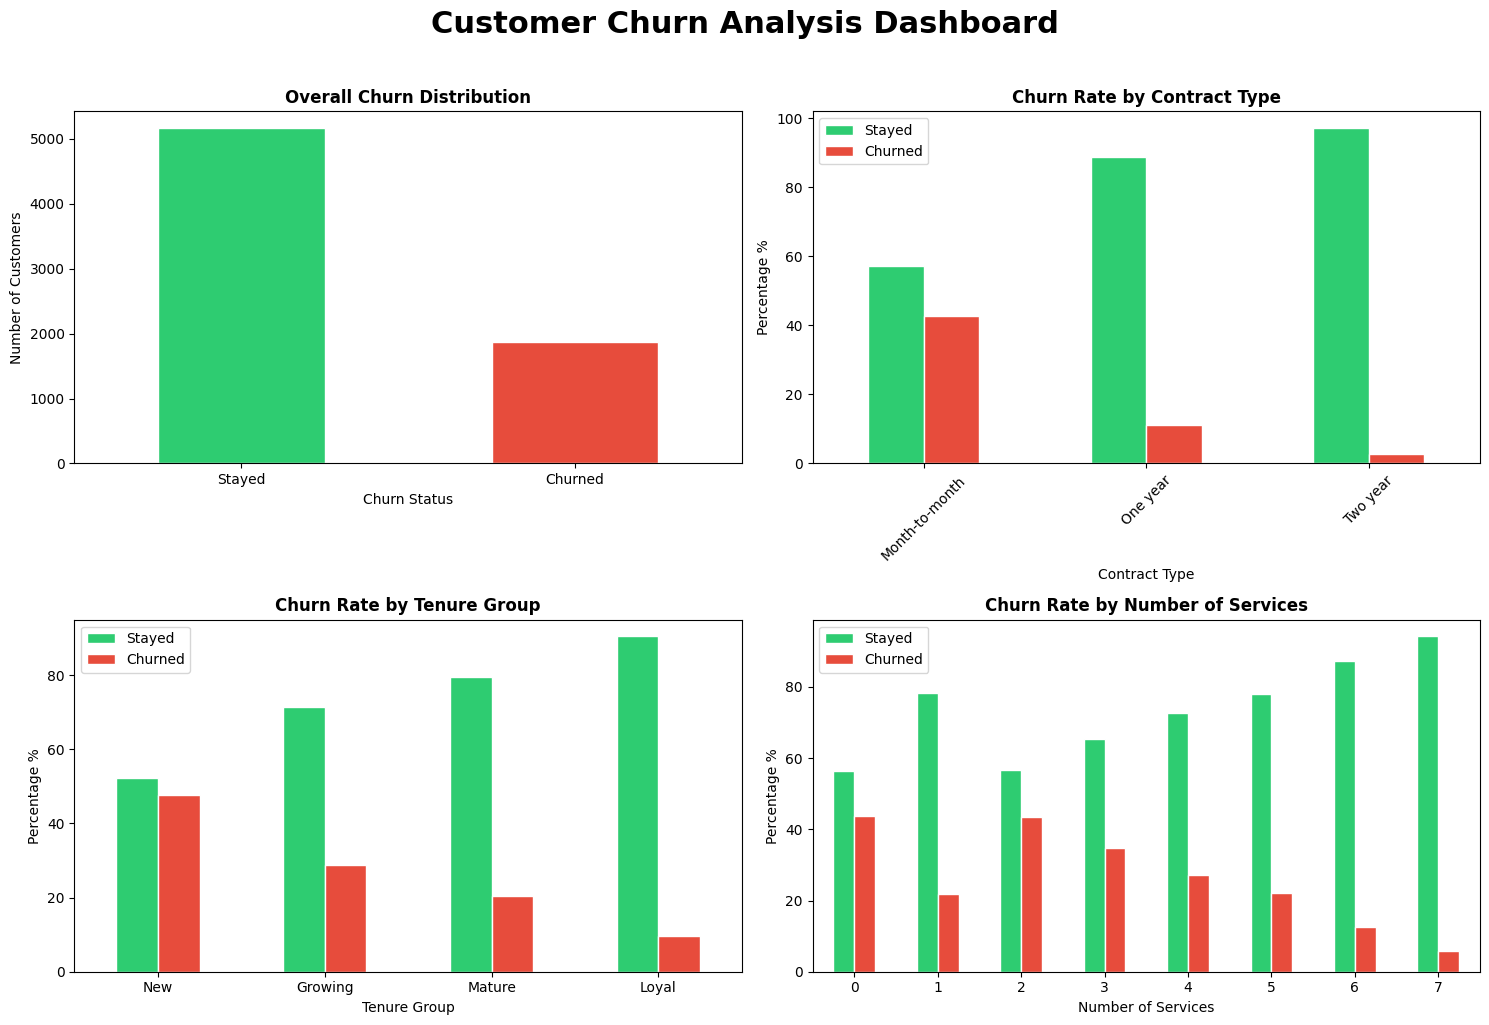

Dashboard saved as churn_dashboard.png ✅


In [33]:
# Final Visualization Dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Customer Churn Analysis Dashboard', 
             fontsize=22, fontweight='bold', y=1.02)

# ── Chart 1: Churn Distribution ──
ax1 = axes[0, 0]
colors = ['#2ecc71', '#e74c3c']
df['Churn'].value_counts().plot(kind='bar', ax=ax1, 
                                 color=colors, edgecolor='white')
ax1.set_title('Overall Churn Distribution', fontweight='bold')
ax1.set_xlabel('Churn Status')
ax1.set_ylabel('Number of Customers')
ax1.set_xticklabels(['Stayed', 'Churned'], rotation=0)

# ── Chart 2: Contract vs Churn ──
ax2 = axes[0, 1]
contract_churn = pd.crosstab(df['Contract'], df['Churn'], 
                              normalize='index') * 100
contract_churn.plot(kind='bar', ax=ax2, 
                    color=colors, edgecolor='white')
ax2.set_title('Churn Rate by Contract Type', fontweight='bold')
ax2.set_xlabel('Contract Type')
ax2.set_ylabel('Percentage %')
ax2.legend(['Stayed', 'Churned'])
ax2.tick_params(axis='x', rotation=45)

# ── Chart 3: Tenure Group vs Churn ──
ax3 = axes[1, 0]
tenure_churn = pd.crosstab(df['tenure_group'], df['Churn'],
                            normalize='index') * 100
tenure_churn.reindex(['New', 'Growing', 'Mature', 'Loyal']).plot(
    kind='bar', ax=ax3, color=colors, edgecolor='white')
ax3.set_title('Churn Rate by Tenure Group', fontweight='bold')
ax3.set_xlabel('Tenure Group')
ax3.set_ylabel('Percentage %')
ax3.legend(['Stayed', 'Churned'])
ax3.tick_params(axis='x', rotation=0)

# ── Chart 4: Total Services vs Churn ──
ax4 = axes[1, 1]
services_churn = pd.crosstab(df['total_services'], df['Churn'],
                              normalize='index') * 100
services_churn.plot(kind='bar', ax=ax4, 
                    color=colors, edgecolor='white')
ax4.set_title('Churn Rate by Number of Services', fontweight='bold')
ax4.set_xlabel('Number of Services')
ax4.set_ylabel('Percentage %')
ax4.legend(['Stayed', 'Churned'])
ax4.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('churn_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as churn_dashboard.png ✅")